# Rangeland Domain — EDA

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'CLAUDE.md').exists())
sys.path.insert(0, str(root))
from config.config import load_config

cfg      = load_config('rangeland_domain')
data_dir = root / cfg['data']['dir']
FILES    = cfg['data']['files']
STATIC   = cfg['columns']['static']
DYNAMIC  = cfg['columns']['dynamic']
TARGETS  = cfg['targets']['fluxes'] + cfg['targets']['pools']
KEEP     = ['site', 'time', 'PFT'] + STATIC + DYNAMIC + TARGETS

dfs  = [pd.read_csv(data_dir / f, usecols=KEEP, parse_dates=['time']) for f in FILES]
data = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(data):,}  |  Unique sites: {data['site'].nunique()}  |  PFT groups: {data['PFT'].nunique()}")

Total rows: 29,723  |  Unique sites: 59  |  PFT groups: 4


## 1. Data Overview

In [3]:
rows = []
for fname, df in zip(FILES, dfs):
    rows.append({
        'File':    fname.split('_predictions')[0],
        'Sites':   df['site'].nunique(),
        'PFT':     ', '.join(df['PFT'].unique()),
        'Start':   df['time'].min().date(),
        'End':     df['time'].max().date(),
        'Records': f"{len(df):,}",
    })
pd.DataFrame(rows).set_index('File')

,Sites,PFT,Start,End,Records
File,,,,,
NEE-desert-scrub,7,desert-scrub,2003-06-05,2024-12-31,"5,384"
NEE-grass,39,grass,2002-01-01,2024-12-31,"16,512"
NEE-grass-tree,6,grass-tree,2002-01-06,2024-12-31,"4,443"
NEE-sagebrush,7,sagebrush,2003-02-05,2024-12-21,"3,384"


## 2. Site Coverage & Time Resolution

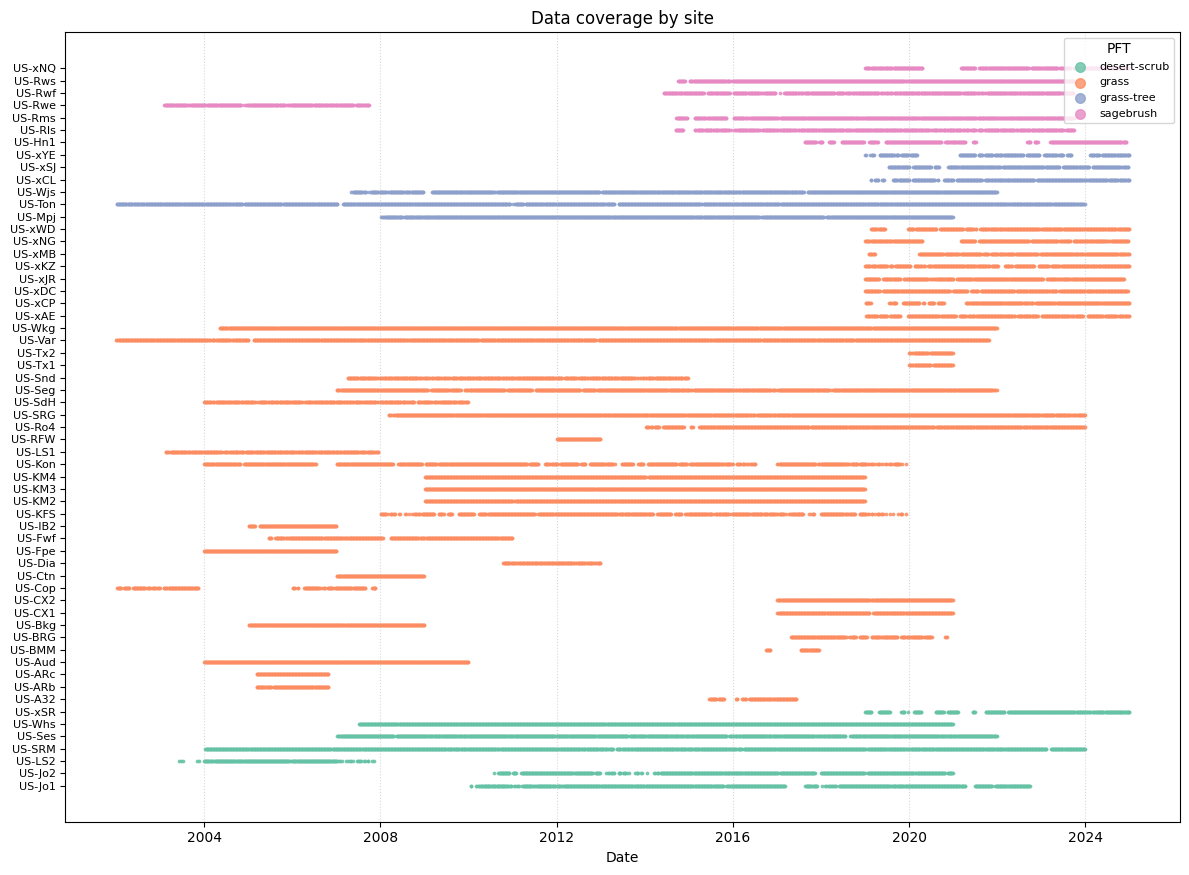

Gap distribution (days between consecutive records):
  min=5  median=5  max=785
  Gaps > 10 days: 509  (1.7%)


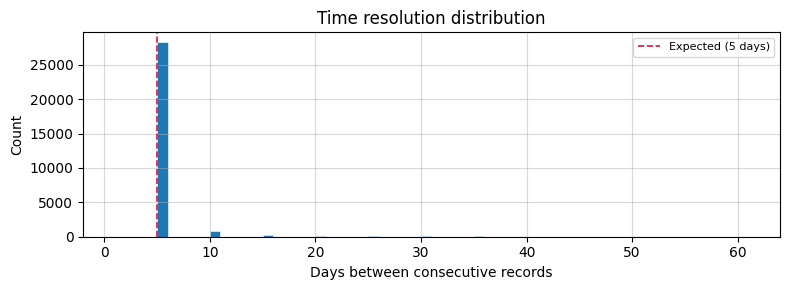

In [7]:
# Coverage plot
sites_meta = (data.sort_values(['PFT', 'site'])
                  .drop_duplicates('site')[['site', 'PFT']]
                  .reset_index(drop=True))
site_idx   = {s: i for i, s in enumerate(sites_meta['site'])}
pft_groups = sites_meta['PFT'].unique()
pft_color  = {pft: plt.cm.Set2.colors[i] for i, pft in enumerate(pft_groups)}

n_sites = len(sites_meta)
fig, ax = plt.subplots(figsize=(12, max(4, n_sites * 0.15)))
seen = set()
for _, row in sites_meta.iterrows():
    sub   = data[data['site'] == row['site']]
    color = pft_color[row['PFT']]
    label = row['PFT'] if row['PFT'] not in seen else None
    ax.scatter(sub['time'], [site_idx[row['site']]] * len(sub),
               s=3, c=[color], alpha=0.8, label=label)
    seen.add(row['PFT'])

ax.set_yticks(range(n_sites))
ax.set_yticklabels(sites_meta['site'], fontsize=8)
ax.set_xlabel('Date')
ax.set_title('Data coverage by site')
ax.legend(title='PFT', loc='upper right', markerscale=4, fontsize=8)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Time resolution
gaps = (data.sort_values(['site', 'time'])
            .groupby('site')['time']
            .diff()
            .dt.days
            .dropna())

print("Gap distribution (days between consecutive records):")
print(f"  min={gaps.min():.0f}  median={gaps.median():.0f}  max={gaps.max():.0f}")
print(f"  Gaps > 10 days: {(gaps > 10).sum():,}  ({(gaps > 10).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(gaps, bins=range(1, min(int(gaps.max()) + 2, 62)), edgecolor='white', linewidth=0.4)
ax.axvline(5, color='crimson', linewidth=1.2, linestyle='--', label='Expected (5 days)')
ax.set_xlabel('Days between consecutive records')
ax.set_ylabel('Count')
ax.set_title('Time resolution distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Missing Values

In [8]:
use_cols = DYNAMIC + STATIC + TARGETS
miss = (data[use_cols]
        .isna()
        .sum()
        .rename('n_missing')
        .to_frame()
        .assign(pct_missing=lambda df: df['n_missing'] / len(data) * 100)
        .sort_values('pct_missing', ascending=False))
miss.index.name = 'column'
miss.style.format({'pct_missing': '{:.2f}%'}).background_gradient(cmap='YlOrRd', subset=['pct_missing'])

,n_missing,pct_missing
column,,
EVI2,0,0.00%
tsoil,0,0.00%
sm1,0,0.00%
sm2,0,0.00%
vpd,0,0.00%
SW_IN_NLDAS,0,0.00%
tavg,0,0.00%
tmax,0,0.00%
tmin,0,0.00%


## 4. Monthly Aggregation Check

Records per site-month:
  min=1  median=6  max=7

Months with < 4 records (potential aggregation issues): 352
  site year_month  n_records
US-A32    2015-06          2
US-A32    2016-01          1
US-A32    2016-02          2
US-A32    2016-03          3
US-A32    2016-04          3
US-A32    2016-05          3
US-A32    2017-06          3
US-ARb    2005-07          3
US-BMM    2016-11          2
US-BMM    2017-12          3
US-BRG    2017-04          1
US-BRG    2018-08          3
US-BRG    2018-10          3
US-BRG    2018-11          3
US-BRG    2019-01          3
US-BRG    2019-02          1
US-BRG    2019-10          1
US-BRG    2020-07          1
US-BRG    2020-10          1
US-BRG    2020-11          2
US-CX1    2019-02          2
US-Cop    2002-02          2
US-Cop    2002-05          3
US-Cop    2002-09          3
US-Cop    2002-10          3
US-Cop    2003-01          1
US-Cop    2003-11          3
US-Cop    2006-02          2
US-Cop    2006-08          3
US-Cop    2006-10   

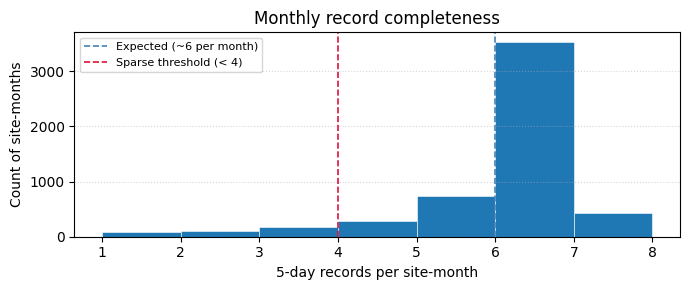

In [5]:
data['year_month'] = data['time'].dt.to_period('M')
recs = (data.groupby(['site', 'year_month'])
            .size()
            .reset_index(name='n_records'))

print("Records per site-month:")
print(f"  min={recs['n_records'].min()}  "
      f"median={recs['n_records'].median():.0f}  "
      f"max={recs['n_records'].max()}")

sparse = recs[recs['n_records'] < 4]
print(f"\nMonths with < 4 records (potential aggregation issues): {len(sparse)}")
if len(sparse):
    print(sparse.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(recs['n_records'], bins=range(1, recs['n_records'].max() + 2),
        edgecolor='white', linewidth=0.4)
ax.axvline(6, color='steelblue', linewidth=1.2, linestyle='--', label='Expected (~6 per month)')
ax.axvline(4, color='crimson',   linewidth=1.2, linestyle='--', label='Sparse threshold (< 4)')
ax.set_xlabel('5-day records per site-month')
ax.set_ylabel('Count of site-months')
ax.set_title('Monthly record completeness')
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Correlation: Dynamic Predictors × Targets

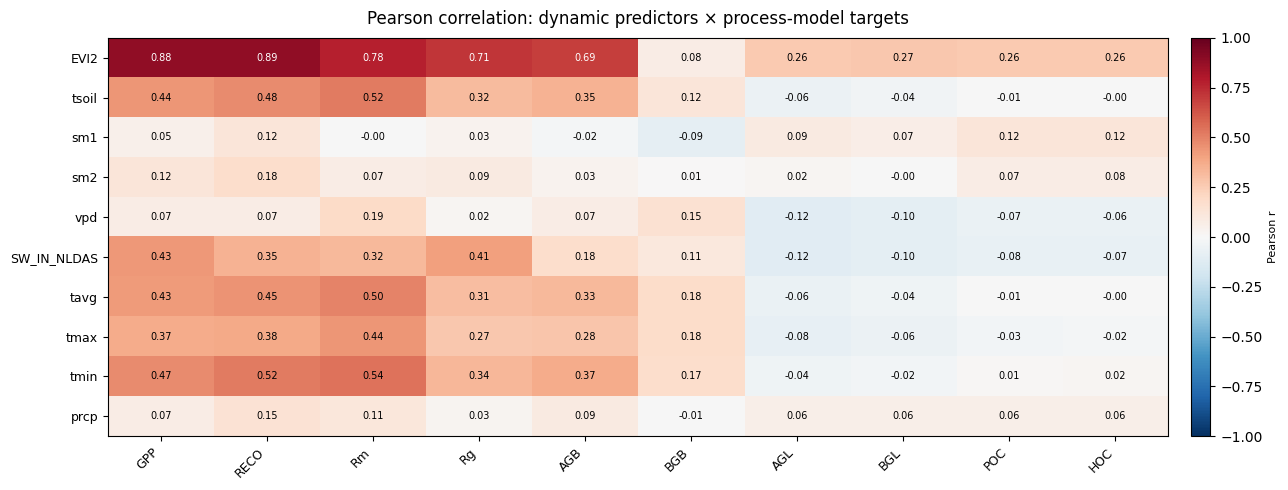

In [6]:
corr = data[DYNAMIC + TARGETS].corr().loc[DYNAMIC, TARGETS]
xtick_labels = [t.replace('_predicted', '') for t in TARGETS]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(TARGETS)))
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(DYNAMIC)))
ax.set_yticklabels(DYNAMIC, fontsize=9)
ax.set_title('Pearson correlation: dynamic predictors × process-model targets', pad=10)

for i in range(len(DYNAMIC)):
    for j in range(len(TARGETS)):
        val = corr.iloc[i, j]
        text_color = 'white' if abs(val) > 0.65 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=7, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Pearson r', fontsize=8)
plt.tight_layout()
plt.show()

## 6. EDA Results & Decisions

### Dataset summary
| | |
|---|---|
| Total records | 29,723 (5-day pentad steps) |
| Sites | 59 across 4 PFT groups |
| PFT breakdown | grass (39 sites), desert-scrub (7), sagebrush (7), grass-tree (6) |
| Time span | 2002–2024 |
| Missing values | **Zero** across all predictors and targets — no imputation needed |

---

### Time resolution & gaps
- Native cadence is 5-day; median gap = 5 days, min = 5 days, max = 785 days.
- **1.7% of steps (509) have gaps > 10 days** — genuine data outages, not regular sampling.
  → During sequence window construction, exclude any window that crosses a gap > 10 days.

---

### Monthly aggregation
- The typical site-month contains 6–7 records (full pentad coverage).
- **352 site-months have < 4 records** (~1.2% of all site-months), scattered across many sites — mostly boundary months at site start/end or around instrument gaps.
  → Drop site-months with < 4 records before aggregating; do not attempt to fill them.

---

### Correlation: dynamic predictors × targets

**Flux targets (GPP, RECO, Rm, Rg)**
- **EVI2 is the dominant predictor** (r = 0.88 / 0.89 for GPP / RECO) — vegetation greenness drives carbon fluxes at this resolution.
- Temperature variables (tmin, tsoil, tavg) contribute moderately (r ≈ 0.4–0.5); SW_IN_NLDAS similarly (r ≈ 0.35–0.43).
- Soil moisture (sm1, sm2) and precipitation are weak (r < 0.2) — likely mediated through EVI2 at monthly scale.

**Pool targets (AGB, BGB, AGL, BGL, POC, HOC)**
- AGB has modest EVI2 correlation (r = 0.69); all other predictors are weak (r < 0.4).
- BGB, AGL, BGL, POC, HOC have near-zero correlations with every dynamic predictor (r ≤ 0.27).
  → Pools carry long-term carbon memory not visible in single-step predictors — the transformer's sequence integration is essential for these targets.

---

### Target scale differences
Fluxes (GPP, RECO, Rm, Rg) are in **g C m⁻² d⁻¹** with means of 0.4–1.9; pools (AGB–HOC) are in **g C m⁻²** with means of 60–7,332. Per-target z-score normalisation is required before training; invert at inference.

---

### Decisions for preprocessing (`01_preprocess.py`)

| Decision | Choice | Rationale |
|---|---|---|
| Aggregation | Mean of pentad records per site-month | Targets are rates/stocks; mean is appropriate |
| Sparse month threshold | Drop months with < 4 records | Avoids biased monthly means from 1–3 records |
| Gap handling | Exclude sequence windows crossing gaps > 10 days | Prevents discontinuous context entering the model |
| PFT encoding | One-hot, concatenated to static features | 4 groups, small cardinality; no embedding needed |
| Normalisation | Per-target + per-feature z-score (fit on train only) | Equalises flux/pool magnitudes; prevents leakage |
| Train/val/test split | Site-level random split (70/15/15) | Avoids spatial leakage; held-out sites are fully unseen |